# Linear Regression from scratch

Math Behind Linear Regression
https://towardsdatascience.com/mathematics-hidden-behind-linear-regression-431fe4d11969/

## Setup

In [10]:
!pip install imageio

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os

## Generate random data


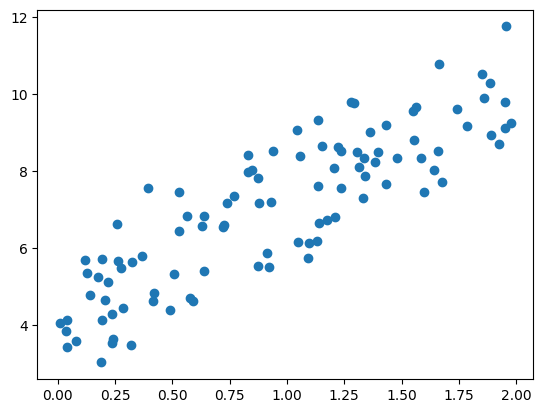

In [12]:
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
# visualize data
plt.scatter(X, y)
plt.show()

## initialize weights and bias (random)

In [13]:
theta = np.random.randn(2, 1)
theta

array([[-0.35399391],
       [-1.37495129]])

## Include the bias term in the linear equation

In [14]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance

# print(X_b)

## Prediction function

In [15]:
def predict(X, theta):
    return X.dot(theta)

## Compute cost function

In [16]:
def compute_cost(X, y, theta):
    m = len(y)
    return (1 / (2 * m)) * np.sum((predict(X, theta) - y) **2)

## Gradient Descent: update weights and bias using gradients

In [17]:
def gradient_descent(X, y, theta, learning_rate, n_iterations):
    os.mkdir('frames')
    m = len(y)
    gradient_history = []
    cost_history = []
    for iteration in range(n_iterations):
        gradients = 1 / m * X.T.dot(predict(X, theta) - y)
        gradient_history.append(gradients)
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        theta = theta - learning_rate * gradients
        
        # Plot and save the frame
        plt.plot(X, y, "b.")
        plt.plot(X, predict(X_b, theta), "r-")
        plt.xlabel("X")
        plt.ylabel("y")
        plt.title(f"Iteration {iteration + 1}")
        plt.savefig(f"frames/frame_{iteration + 1}.png")
        plt.clf()
    return theta, gradient_history, cost_history

## Train model

In [18]:
learning_rate = 0.01
n_iterations = 200
theta, gradient_history, cost_history = gradient_descent(X_b, y, theta, learning_rate, n_iterations)

<Figure size 640x480 with 0 Axes>

## Line fitting X, y Data

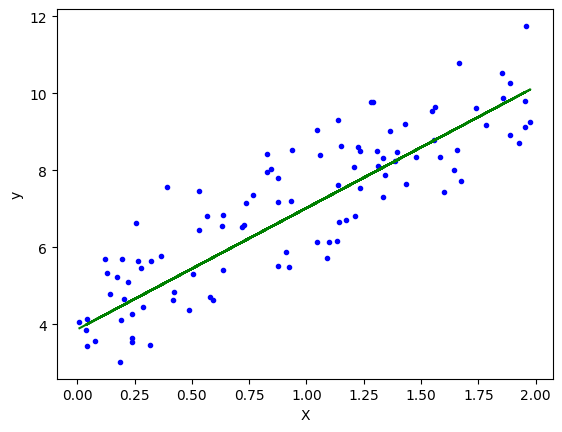

In [19]:
plt.plot(X, y, "b.")
plt.plot(X, predict(X_b, theta), "g-")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## Gradien Descent History

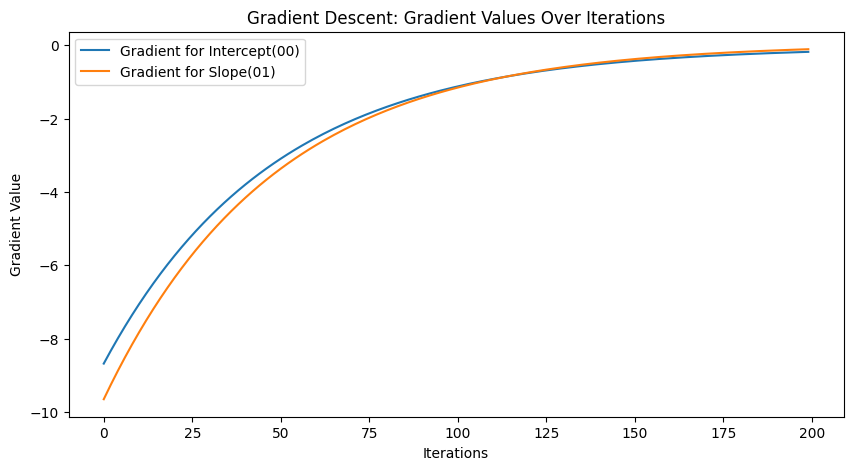

In [20]:
gradient_history = np.array(gradient_history)
plt.figure(figsize=(10, 5))
plt.plot(gradient_history[:, 0], label='Gradient for Intercept(00)')
plt.plot(gradient_history[:, 1], label='Gradient for Slope(01)')
plt.xlabel('Iterations')
plt.ylabel('Gradient Value')
plt.legend()
plt.title('Gradient Descent: Gradient Values Over Iterations')
plt.show()

## Cost Function

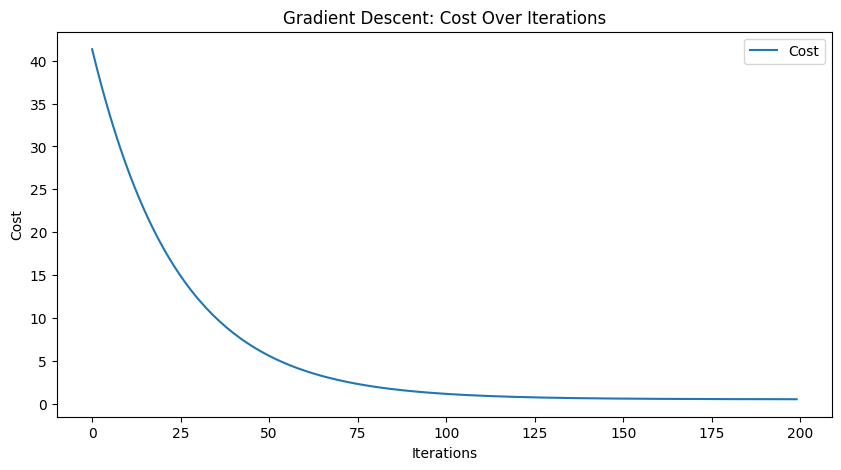

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(cost_history, label='Cost')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Gradient Descent: Cost Over Iterations')
plt.legend()

## Create a GIF with the fitting line adjusting to data

In [22]:
with imageio.get_writer('linear_regression.gif', mode='I') as writer:
    for iteration in range(n_iterations):
        image = imageio.imread(f"frames/frame_{iteration + 1}.png")
        writer.append_data(image)

# Clean up frames directory
for filename in os.listdir('frames'):
    os.remove(f"frames/{filename}")
os.rmdir('frames')

print("GIF created successfully!")

C:\Users\ramir\AppData\Local\Temp\ipykernel_24452\778291462.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"frames/frame_{iteration + 1}.png")


GIF created successfully!
